In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random

from IPython.display import Image, display
from IPython.display import Video
import cv2

%pip install ultralytics
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

import warnings
warnings.filterwarnings('ignore')

Ultralytics 8.3.100 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6170.1/8062.4 GB disk)


In [2]:
# get path of images in files
train_img = '/kaggle/input/ufpr-alpr-yolo/train/images'
valid_img = '/kaggle/input/ufpr-alpr-yolo/valid/images'
test_img = '/kaggle/input/ufpr-alpr-yolo/test/images'

# get path of labels  files
train_lbl = '/kaggle/input/ufpr-alpr-yolo/train/labels'
valid_lbl = '/kaggle/input/ufpr-alpr-yolo/valid/labels'
test_lbl = '/kaggle/input/ufpr-alpr-yolo/test/labels'

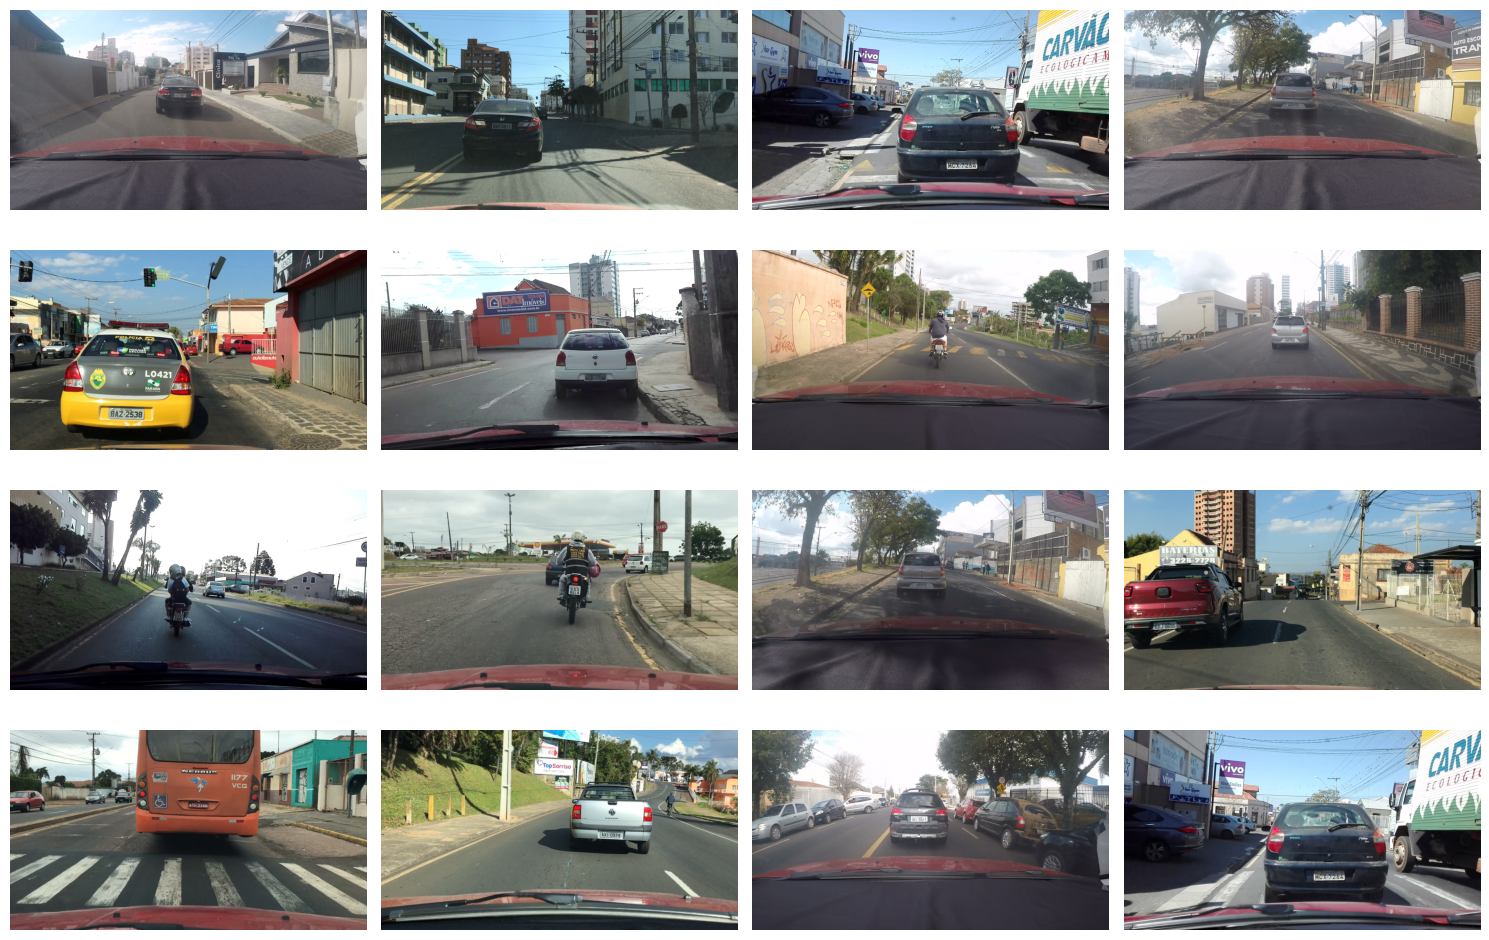

In [3]:
# get all images in train data
image_files = [f for f in os.listdir(train_img) if f.endswith('.png')]

# chosse random 16 image from this folder
random_images = random.sample(image_files, 16)

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for i, img_name in enumerate(random_images):

    # read image
    img_path = os.path.join(train_img, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #plotting
    row, col = divmod(i, 4)
    axs[row, col].imshow(img)
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Define a function to write text to a file
def write_text_to_file(text, file_path):
    with open(file_path, 'w') as file:
        file.write(text)

text = """
names:
- License_Plate
nc: 1

train: /kaggle/input/ufpr-alpr-yolo/train/images
val: /kaggle/input/ufpr-alpr-yolo/valid/images
test: /kaggle/input/ufpr-alpr-yolo/test/images
"""

write_text_to_file(text, "data.yaml")

In [5]:
!yolo task= detect mode= train data=/kaggle/working/data.yaml model=yolo11n.pt epochs=60 imgsz=1024,576 batch=16

100%|██████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 77.8MB/s]
Ultralytics 8.3.100 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/working/data.yaml, epochs=60, time=None, patience=100, batch=16, imgsz=(1024, 576), save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=

In [6]:
result = pd.read_csv('/kaggle/working/runs/detect/train/results.csv')
result.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
55,56,5472.50,0.39458,0.23806,0.77698,0.99738,0.99889,0.99499,0.82572,0.73763,0.33617,0.85432,0.000185,0.000185,0.000185
56,57,5570.36,0.40191,0.23733,0.78317,0.99752,0.99889,0.99500,0.82117,0.75385,0.34424,0.85751,0.000152,0.000152,0.000152
57,58,5666.68,0.39058,0.23151,0.78219,0.99778,0.99730,0.99497,0.82179,0.74333,0.34553,0.85603,0.000119,0.000119,0.000119
58,59,5762.06,0.39668,0.23386,0.77846,0.99762,0.99778,0.99498,0.82277,0.73719,0.34223,0.85483,0.000086,0.000086,0.000086
59,60,5856.85,0.38821,0.23295,0.78117,0.99730,0.99778,0.99497,0.82435,0.73321,0.34287,0.85392,0.000053,0.000053,0.000053


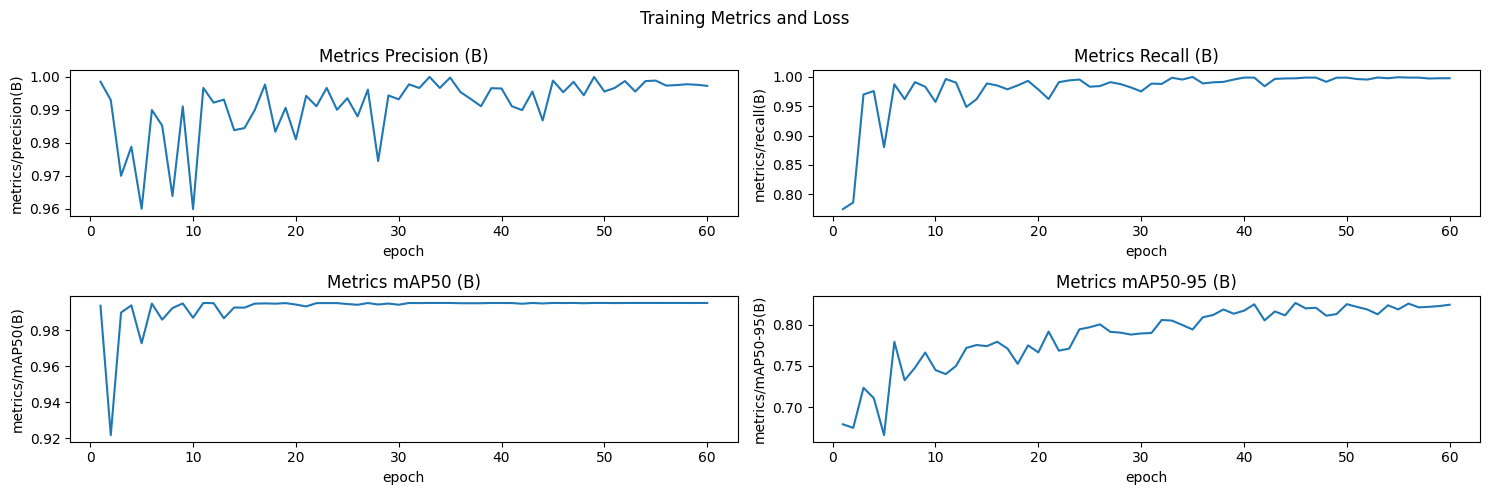

In [7]:
result.columns = result.columns.str.strip()

# Create subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='metrics/precision(B)', data=result, ax=axs[0,0])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=result, ax=axs[0,1])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=result, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=result, ax=axs[1,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Metrics Precision (B)')
axs[0,1].set(title='Metrics Recall (B)')
axs[1,0].set(title='Metrics mAP50 (B)')
axs[1,1].set(title='Metrics mAP50-95 (B)')

plt.suptitle('Training Metrics and Loss')
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

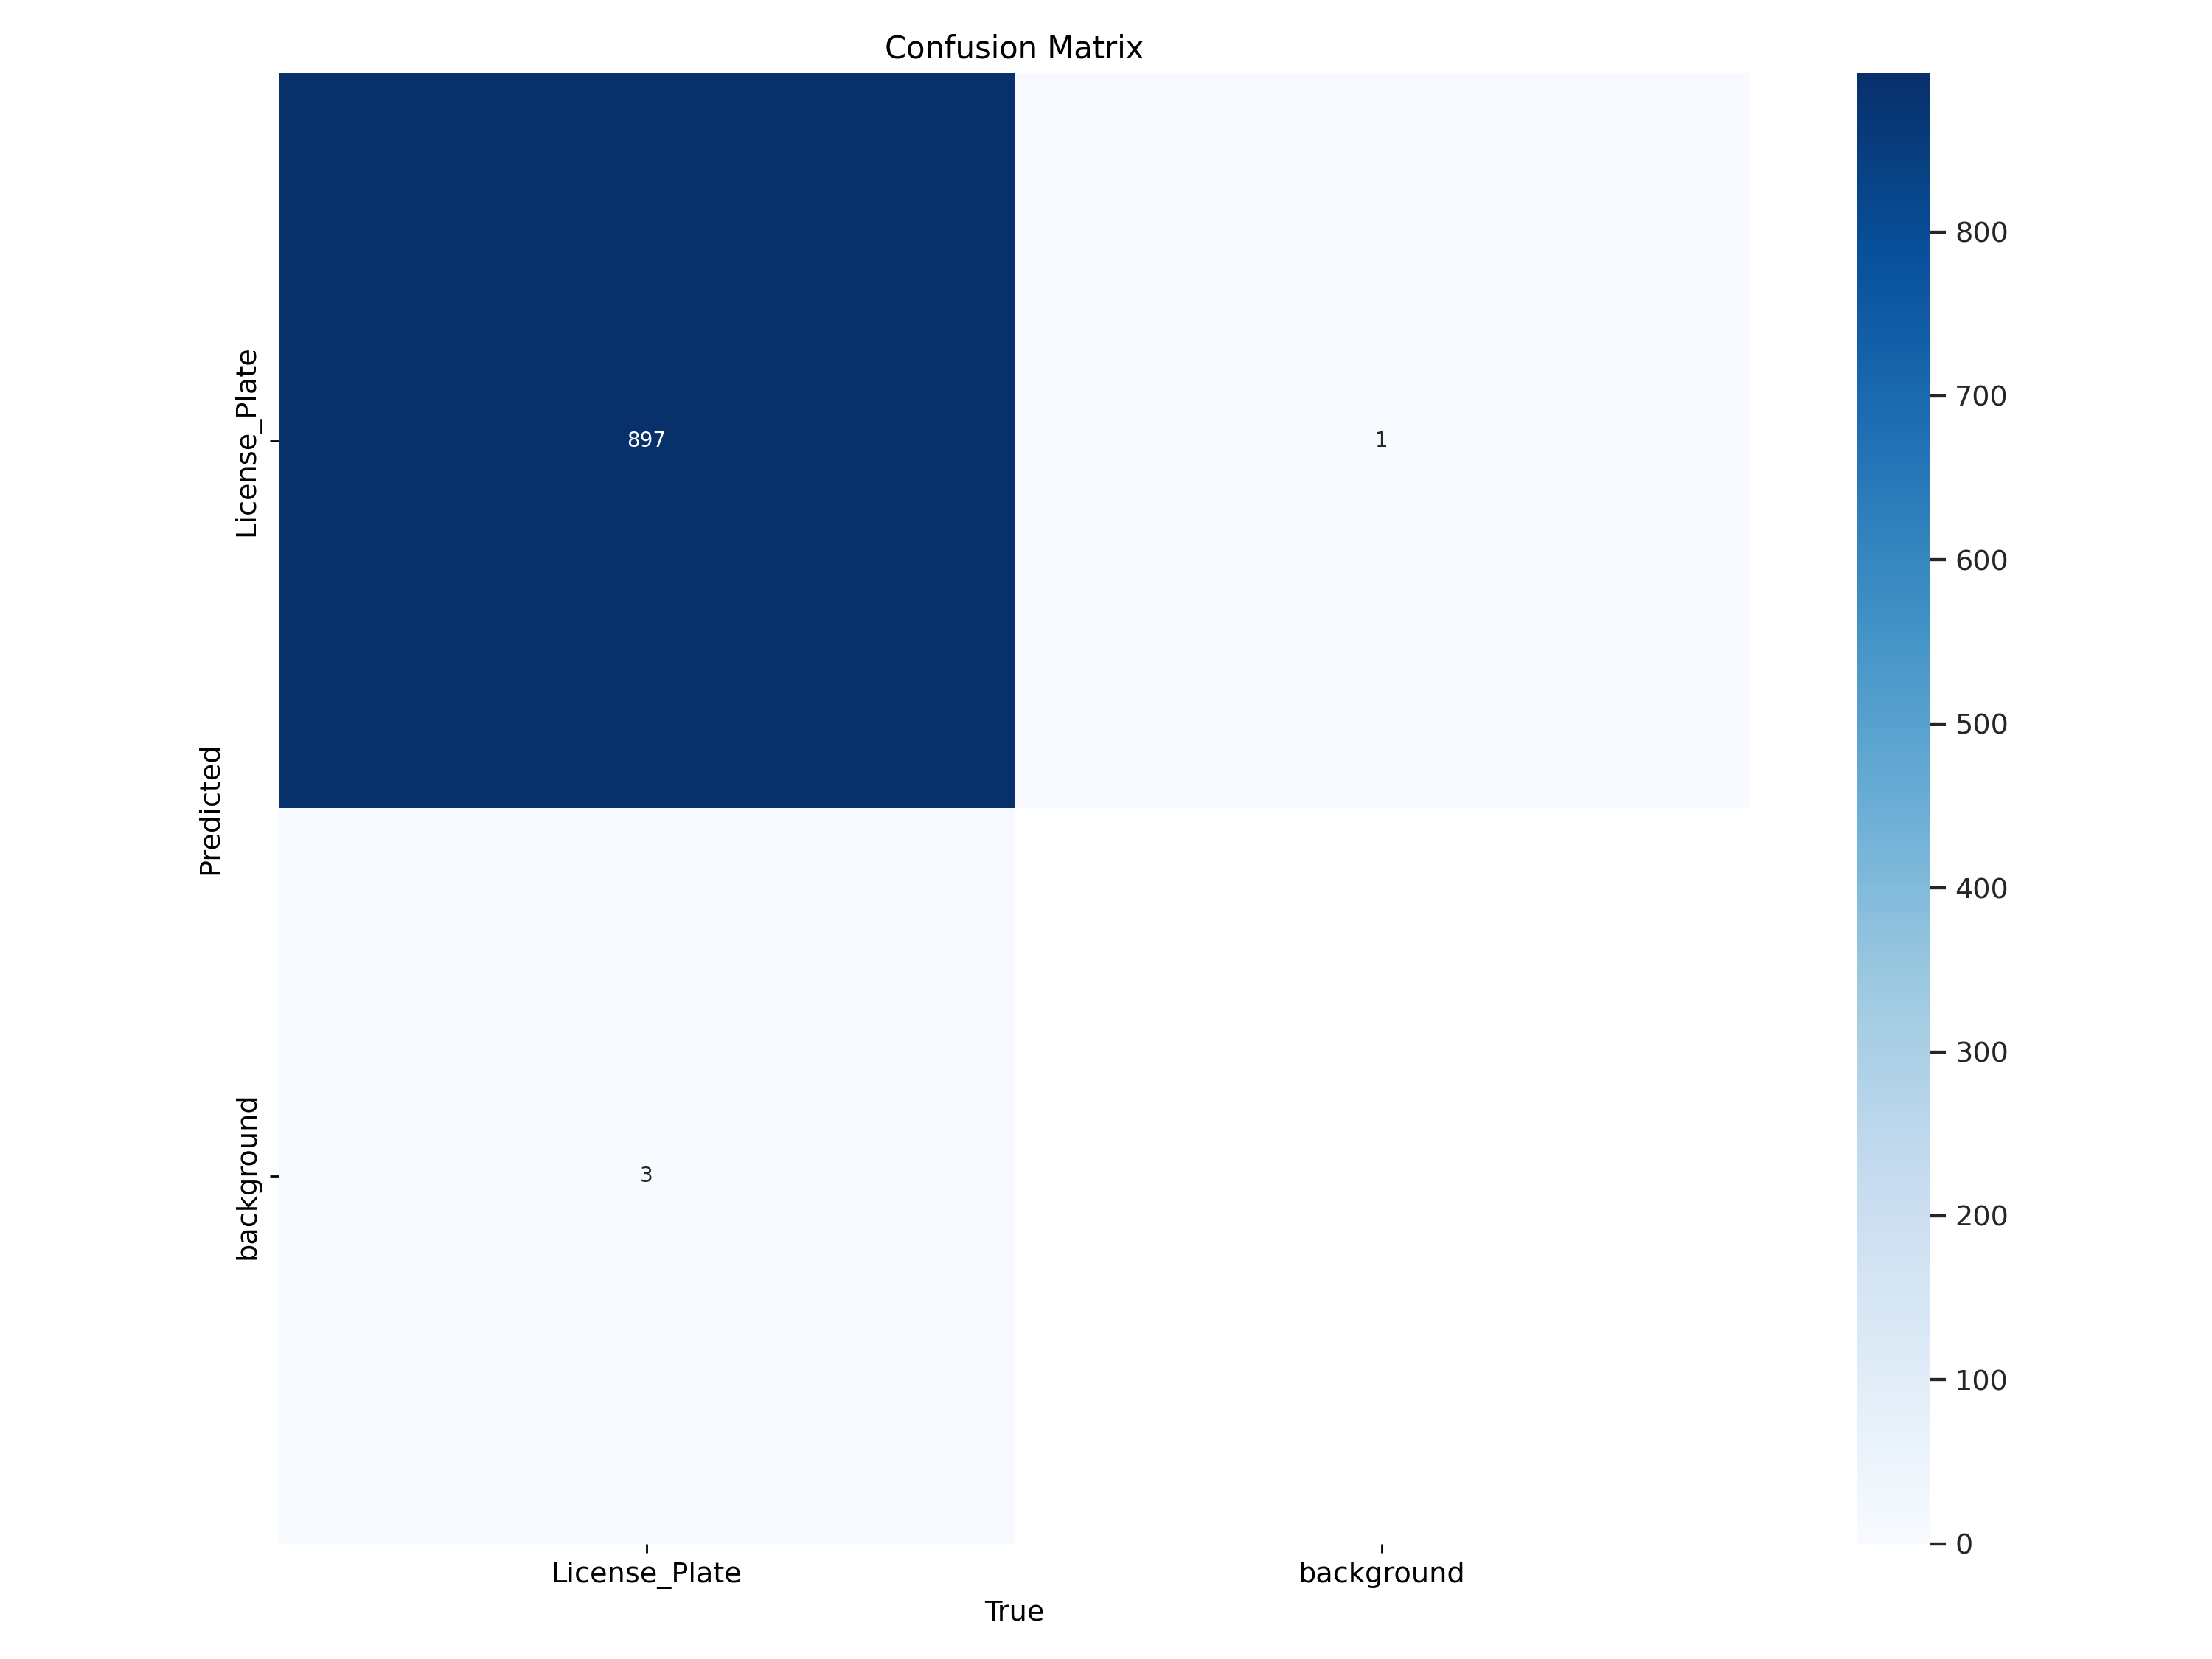

In [8]:
display(Image(filename=f"/kaggle/working/runs/detect/train/confusion_matrix.png", width=700))

In [10]:
!yolo task=detect mode=predict model=/kaggle/working/runs/detect/train/weights/best.pt imgsz=1024 conf=0.5 \ source=/kaggle/input/ufpr-alpr-yolo/test/images

Ultralytics 8.3.100 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

image 1/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_01.png: 576x1024 1 License_Plate, 47.8ms
image 2/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_02.png: 576x1024 1 License_Plate, 9.8ms
image 3/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_03.png: 576x1024 1 License_Plate, 9.4ms
image 4/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_04.png: 576x1024 1 License_Plate, 9.2ms
image 5/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_05.png: 576x1024 1 License_Plate, 9.6ms
image 6/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_06.png: 576x1024 1 License_Plate, 11.1ms
image 7/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_07.png: 576x1024 1 License_Plate, 9.7ms
image 8/1800 /kaggle/input/ufpr-alpr-yolo/test/images/track0091_08.png: 576x1024 1 License_

In [ ]:
# Đường dẫn và tham số
model_path = "/kaggle/working/runs/detect/train/weights/best.pt"  # Đường dẫn tới mô hình YOLO đã huấn luyện
test_folder = "/kaggle/input/ufpr-alpr-yolo/test/images"  # Thư mục chứa ảnh test
output_folder = "/kaggle/working/runs/cropped_license_plates"  # Thư mục để lưu ảnh đã crop
offset = 20  # Độ mở rộng bounding box (pixel)

# Tạo thư mục output nếu chưa tồn tại
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Load mô hình YOLO
model = YOLO(model_path)

# Hàm crop và lưu ảnh với offset
def crop_and_save(image, box, output_path, offset):
    x1, y1, x2, y2 = map(int, box)  # Chuyển tọa độ về integer
    h, w = image.shape[:2]
    
    # Thêm offset và đảm bảo không vượt quá kích thước ảnh
    x1 = max(0, x1 - offset)
    y1 = max(0, y1 - offset)
    x2 = min(w, x2 + offset)
    y2 = min(h, y2 + offset)
    
    # Crop ảnh
    cropped_image = image[y1:y2, x1:x2]
    
    # Lưu ảnh đã crop
    cv2.imwrite(output_path, cropped_image)

# Xử lý từng ảnh trong thư mục test
for image_name in os.listdir(test_folder):
    if image_name.endswith(('.jpg', '.jpeg', '.png')):  # Chỉ xử lý file ảnh
        image_path = os.path.join(test_folder, image_name)
        image = cv2.imread(image_path)
        
        # Dự đoán với YOLO
        results = model(image)
        
        # Lấy bounding box từ kết quả
        for i, result in enumerate(results[0].boxes.xyxy):  # xyxy là định dạng [x1, y1, x2, y2]
            output_name = f"{os.path.splitext(image_name)[0]}_crop_{i}.jpg"
            output_path = os.path.join(output_folder, output_name)
            
            # Crop và lưu
            crop_and_save(image, result, output_path, offset)
            print(f"Saved cropped image: {output_path}")

print("Hoàn tất crop tất cả object!")


0: 576x1024 1 License_Plate, 49.6ms
Speed: 9.2ms preprocess, 49.6ms inference, 179.3ms postprocess per image at shape (1, 3, 576, 1024)
Saved cropped image: /kaggle/working/runs/cropped_license_plates/track0098_27_crop_0.jpg

0: 576x1024 1 License_Plate, 9.6ms
Speed: 4.8ms preprocess, 9.6ms inference, 1.3ms postprocess per image at shape (1, 3, 576, 1024)
Saved cropped image: /kaggle/working/runs/cropped_license_plates/track0107_18_crop_0.jpg

0: 576x1024 1 License_Plate, 9.8ms
Speed: 5.2ms preprocess, 9.8ms inference, 1.4ms postprocess per image at shape (1, 3, 576, 1024)
Saved cropped image: /kaggle/working/runs/cropped_license_plates/track0144_11_crop_0.jpg

0: 576x1024 1 License_Plate, 9.5ms
Speed: 5.1ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 576, 1024)
Saved cropped image: /kaggle/working/runs/cropped_license_plates/track0121_26_crop_0.jpg

0: 576x1024 1 License_Plate, 15.6ms
Speed: 4.8ms preprocess, 15.6ms inference, 2.5ms postprocess per image 

In [ ]:
# get all images in train data
predict_img = '/kaggle/working/runs/detect/predict'
image_files = [f for f in os.listdir(predict_img) if f.endswith('.jpg')]

# chosse random 16 image from this folder
random_images = random.sample(image_files, 16)

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for i, img_name in enumerate(random_images):

    # read image
    img_path = os.path.join(predict_img, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #plotting
    row, col = divmod(i, 4)
    axs[row, col].imshow(img)
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()